In [33]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA   # ★ 추가: PCA
import joblib  # to make a file, that I've trained the model 



df = pd.read_csv('/Users/odaniel/Desktop/2025 2학기/빅데이터 개론/프로젝트 /singlecellRNA/GSE183947_fpkm 복사본.csv')

# 유잔자 이름을 index로 설정
df = df.rename(columns={'Unnamed: 0': 'gene'})
df = df.set_index('gene')
#나중에 최종적으로 추측할 데이터, 1, 30번 째, CA와 CAP sample을 학습 모델의 데이터에서 제외시킨다.
r = df.drop(df.columns[[0,1,2,30,31,32]], axis=1)

#샘플 기준으로 뒤집기(행 = 샘플, 열 = 유전자)
data = r.T #transpose the data

data.sample

<bound method NDFrame.sample of gene         TSPAN6   TNMD   DPM1  SCYL3  C1orf112    FGR    CFH  FUCA2  \
CA.109745      5.45   0.00   3.43   4.58      6.24   4.23   2.59  23.78   
CA.1906415     4.52   0.00   8.45   7.20      5.16  15.87   9.21  14.95   
CA.1912627     4.75   0.00   8.53   6.03     13.69   8.56   8.22   7.11   
CA.1924346     3.96   0.00   7.80   9.05      6.69  13.28  15.64  14.03   
CA.1926760     3.58   0.23   7.62   5.37      5.28  12.27   4.06  19.77   
CA.1927842     6.41   0.39   6.40   5.92      7.65   5.58   5.52  18.31   
CA.1933414    11.89   0.44   6.09  12.45     13.71   7.03   8.67  11.55   
CA.1940640     5.55   0.36   6.62  10.44     13.97   5.04   7.12  17.55   
CA.2004407     3.82   0.09   5.51   8.81      7.30  12.83  10.55  16.79   
CA.2005288     7.66   0.07   9.62   9.04     16.13   9.56  11.03  31.40   
CA.2006047    11.48   1.14   6.77   9.36     14.37   7.57   9.05  26.49   
CA.2008260     4.32   0.00  13.13   5.91     10.71   9.77  14.16  33

In [34]:
# 4) 암/정상 라벨 만들기
# CA.로 시작하면 1(암), CAP.로 시작하면 0(정상)
labels = data.index.to_series().str.startswith('CA.').astype(int)
 
# 확인
labels.value_counts() # 0이 몇 개, 1이 몇 개인지

1    27
0    27
Name: count, dtype: int64

In [ ]:
# ===============================
# Train / Test split
# ===============================

X = data   # 정리된 feature 데이터 (samples × genes)d
y = labels # 라벨 데이터 (CA=1, CAP=0)
# Train / Test 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        # CA / CAP 비율 유지
    random_state=42    # 재현성 확보
)


# ===============================
# PCA 적용 (Dimensionality Reduction)
# ===============================

from sklearn.decomposition import PCA

# PCA: 약 20,000개 유전자 차원을 10차원으로 축소
pca = PCA(n_components=10)
pca.fit(X_train)

# PCA는 feature(X)에만 적용 (label y에는 적용하지 않음)
# Train 데이터로만 PCA 학습 (data leakage 방지)
pca.fit(X_train)

# Train / Test 데이터 PCA 변환
X_train_pca = pca.transform(X_train)
X_test_pca  = pca.transform(X_test)


# ===============================
# MATLAB 시각화를 위한 PCA 결과 저장
# ===============================

import scipy.io as sio

# PC1, PC2만 저장 (2D PCA 시각화용)
sio.savemat(
    "pca_visualization.mat",
    {
        "PC": X_train_pca[:, :2],
        "labels": y_train.to_numpy()
    }
)


# ===============================
# Decision Tree 모델 학습
# ===============================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Decision Tree 모델 생성
model = DecisionTreeClassifier(random_state=42) # 동일한 결과를 위한 랜덤 시드
model.fit(X_train_pca, y_train) # PCA된 Train 데이터로 학습


# ===============================
# Test 데이터로 예측 및 성능 평가
# ===============================

# Test 데이터 예측
predictions = model.predict(X_test_pca)

# Accuracy 계산
score = accuracy_score(y_test, predictions)
print("Test Accuracy:", score)


Test Accuracy: 1.0


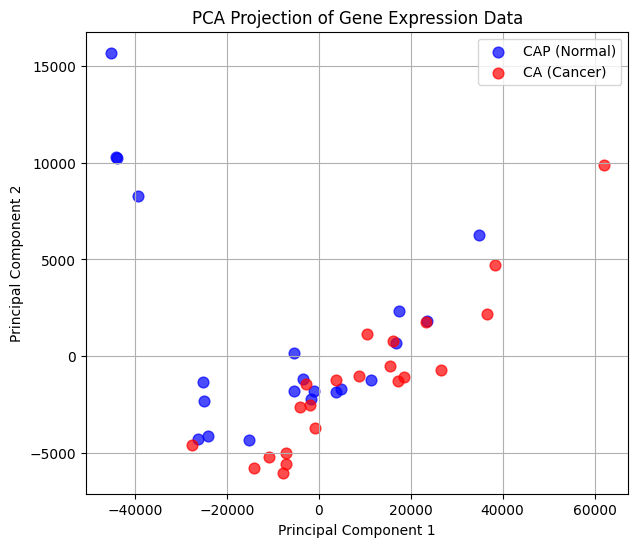

In [36]:
# ===============================
# PCA 2D Visualization (Jupyter)
# ===============================

import matplotlib.pyplot as plt



plt.figure(figsize=(7, 6))

# 정상(CAP = 0)
plt.scatter(
    X_train_pca[y_train == 0, 0],
    X_train_pca[y_train == 0, 1],
    c='blue',
    label='CAP (Normal)',
    alpha=0.7,
    s=60
)

# 암(CA = 1)
plt.scatter(
    X_train_pca[y_train == 1, 0],
    X_train_pca[y_train == 1, 1],
    c='red',
    label='CA (Cancer)',
    alpha=0.7,
    s=60
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Gene Expression Data')
plt.legend()
plt.grid(True)
plt.show()


In [37]:
#이제 학습한 모델을 새로운 파일에 저장

# 학습한 모델을 새로운 파일에 따로 저장한다.
joblib.dump(
    {"model": model, "pca": pca},
    "CancerPrediction_FPKM.pkl"
)

['CancerPrediction_FPKM.pkl']

===== 개별 샘플 예측 결과 =====
1. 샘플: CA.102548  |  실제: 암(CA)  /  예측: 암(CA)
2. 샘플: CA.104338  |  실제: 암(CA)  /  예측: 암(CA)
3. 샘플: CA.105094  |  실제: 암(CA)  /  예측: 정상(CAP)
4. 샘플: CAP.102548  |  실제: 정상(CAP)  /  예측: 정상(CAP)
5. 샘플: CAP.104338  |  실제: 정상(CAP)  /  예측: 정상(CAP)
6. 샘플: CAP.105094  |  실제: 정상(CAP)  /  예측: 정상(CAP)

외부 6개 샘플에 대한 Accuracy: 0.833  (5/6)

===== Confusion Matrix =====
[[3 0]
 [1 2]]

행 = 실제 라벨 (0=정상, 1=암)
열 = 예측 라벨 (0=정상, 1=암)

===== Classification Report =====
              precision    recall  f1-score   support

     정상(CAP)       0.75      1.00      0.86         3
       암(CA)       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/odaniel/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/odaniel/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/odanie

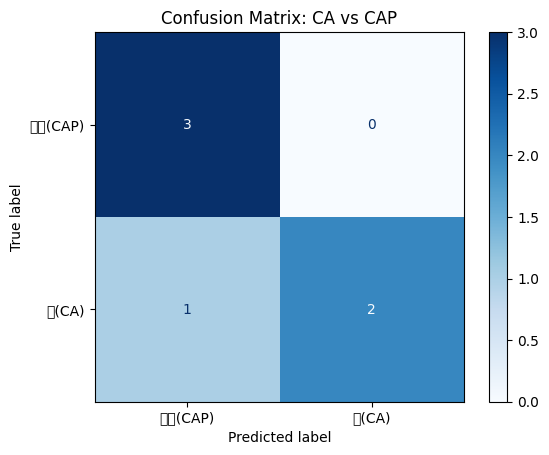

In [ ]:
#이제 저장된 모델을 불러오기 load
saved = joblib.load("CancerPrediction_FPKM.pkl")
learned_model = saved["model"]
learned_pca   = saved["pca"]



#테스트 할 데이터 1,30번 컬럼 친구 따로 데이터 값 구하기. 
Testdf = pd.read_csv('/Users/odaniel/Desktop/2025 2학기/빅데이터 개론/프로젝트 /singlecellRNA/GSE183947_fpkm 복사본.csv')

# 유잔자 이름을 index로 설정
Testdf = Testdf.rename(columns={'Unnamed: 0': 'gene'})
Testdf = Testdf.set_index('gene')   


a = Testdf.iloc[:, [0,1,2,30,31,32]]

data_T = a.T #transpose the data

CA_arr = data_T.iloc[[0,1,2]].to_numpy() 
CAP_arr = data_T.iloc[[3,4,5]].to_numpy()

#PCA
CA_arr_pca  = learned_pca.transform(CA_arr)
CAP_arr_pca = learned_pca.transform(CAP_arr)



#하나의 X_test로 만들기
X_smaple_Text = np.vstack([CA_arr, CAP_arr])  # (6개의 value 배령들이 하나로)

#정답이 들어어 있는 배열, 곧 CA, CAP가 3개씩 들어있어서 CA는 1, CAP는 0
y_answer = np.array([1,1,1,0,0,0])


#sample_names 
sample_names =      ['CA.102548', 'CA.104338', 'CA.105094', 'CAP.102548', 'CAP.104338','CAP.105094']


# for name, true, pred in zip(sample_names, y_sample_Test, y_)


# PCA 변환
X_ext_pca = learned_pca.transform(X_smaple_Text)  # (6, n_components)

# 예측
y_pred_ext = learned_model.predict(X_ext_pca)




correct = 0

print("===== 개별 샘플 예측 결과 =====")
for i, (name, true_label, pred_label) in enumerate(zip(sample_names, y_answer, y_pred_ext)):
    true_txt = "암(CA)" if true_label == 1 else "정상(CAP)"
    pred_txt = "암(CA)" if pred_label == 1 else "정상(CAP)"
    
    print(f"{i+1}. 샘플: {name}  |  실제: {true_txt}  /  예측: {pred_txt}")
    
    if true_label == pred_label:
        correct += 1


# ===== 전체 Accuracy 출력 =====
acc_ext = accuracy_score(y_answer, y_pred_ext)
print(f"\n외부 6개 샘플에 대한 Accuracy: {acc_ext:.3f}  ({correct}/{len(y_answer)})")


# ===== Confusion Matrix 출력 =====
print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_answer, y_pred_ext)
print(cm)

# 사람이 보기 좋게 라벨 붙여서 출력
print("\n행 = 실제 라벨 (0=정상, 1=암)")
print("열 = 예측 라벨 (0=정상, 1=암)")

# ===== Precision / Recall / F1-score =====
print("\n===== Classification Report =====")
print(classification_report(y_answer, y_pred_ext, target_names=["정상(CAP)", "암(CA)"]))


# ===== Confusion Matrix 시각화 (여기!) =====
from sklearn.metrics import ConfusionMatrixDisplay


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["정상(CAP)", "암(CA)"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: CA vs CAP")
plt.show()


